# 机器学习练习 1 - 线性回归

假设您是一个运输食物的货车公司的 CEO，现在需要添加一个货车。根据公司已经有货车，来决定在哪个城市投放。
数据 ex1data1.txt ：第一列是城市的人口规模，第二列是该城市每个食物货车的利润。


## 单变量线性回归

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
path = 'ex1data1.txt'
data = pd.read_csv(path, header=None, names=['Population', 'Profit'])
data.head(10)

,Population,Profit
0,6.1101,17.5920
1,5.5277,9.1302
2,8.5186,13.6620
3,7.0032,11.8540
4,5.8598,6.8233
5,8.3829,11.8860
6,7.4764,4.3483
7,8.5781,12.0000
8,6.4862,6.5987
9,5.0546,3.8166


In [30]:
print(type(data))
data.describe()

<class 'pandas.core.frame.DataFrame'>


,Population,Profit
count,97.000000,97.000000
mean,8.159800,5.839135
std,3.869884,5.510262
min,5.026900,-2.680700
25%,5.707700,1.986900
50%,6.589400,4.562300
75%,8.578100,7.046700
max,22.203000,24.147000


看下数据长什么样子

现在让我们使用梯度下降来实现线性回归，以最小化成本函数。 以下代码示例中实现的方程在“练习”文件夹中的“ex1.pdf”中有详细说明。

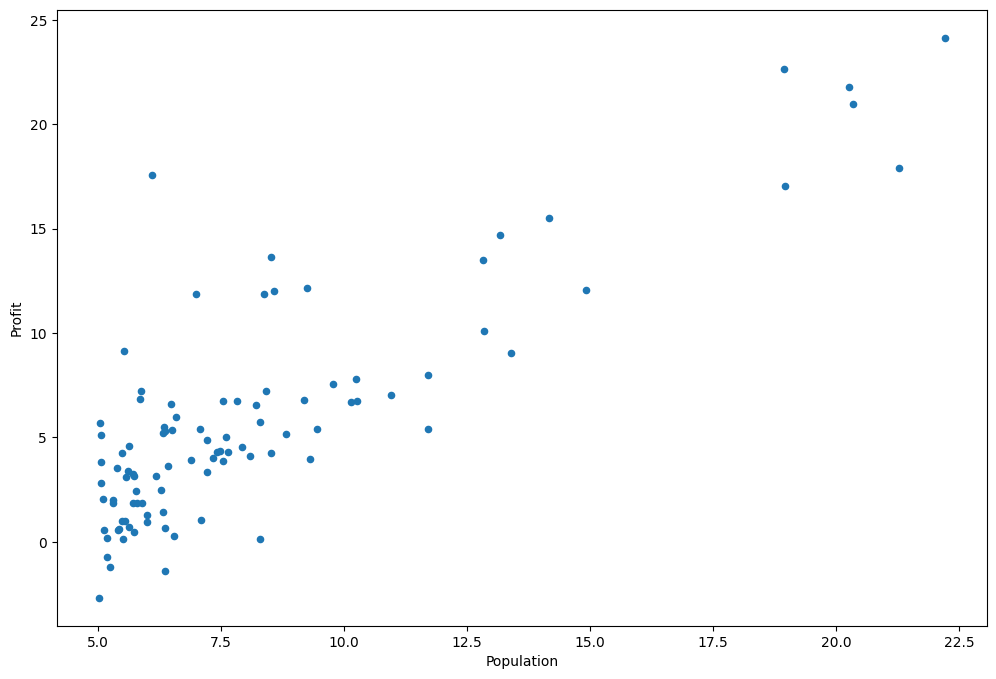

In [15]:
data.plot(kind='scatter', x='Population', y='Profit', figsize=(12, 8))
plt.show()

首先，我们将创建一个以参数θ为特征函数的代价函数
$$J\left( \theta  \right)=\frac{1}{2m}\sum\limits_{i=1}^{m}{{{\left( {{h}_{\theta }}\left( {{x}^{(i)}} \right)-{{y}^{(i)}} \right)}^{2}}}$$
其中：\\[{{h}_{\theta }}\left( x \right)={{\theta }^{T}}X={{\theta }_{0}}+{{\theta }_{1}}{{x}}\\]

In [16]:
def computeCost(X, y, theta):
    inner = np.power(((X * theta.T) - y), 2)
    return np.sum(inner) / (2 * len(X))

让我们在训练集中添加一列，以便我们可以使用向量化的解决方案来计算代价和梯度。

In [17]:
print(type(data))
data.insert(0, 'Ones', 1)

<class 'pandas.core.frame.DataFrame'>


现在我们来做一些变量初始化。

In [18]:
# set X (training data) and y (target variable)
cols = data.shape[1]
X = data.iloc[:, 0:cols - 1]  #X是所有行，去掉最后一列
y = data.iloc[:, cols - 1:cols]  #X是所有行，最后一列

观察下 X (训练集) and y (目标变量)是否正确.

In [19]:
X.head()  #head()是观察前5行

,Ones,Population
0,1,6.1101
1,1,5.5277
2,1,8.5186
3,1,7.0032
4,1,5.8598


In [20]:
y.head()

,Profit
0,17.5920
1,9.1302
2,13.6620
3,11.8540
4,6.8233


代价函数是应该是numpy矩阵，所以我们需要转换X和Y，然后才能使用它们。 我们还需要初始化theta。

In [21]:
X = np.matrix(X.values)
y = np.matrix(y.values)
theta = np.matrix(np.array([10, 5]))

theta 是一个(1,2)矩阵

In [22]:
theta

matrix([[0, 0]])

看下维度

In [23]:
X.shape, theta.shape, y.shape

# ((97, 2) x (2, 1) = (97, 1))

((97, 2), (1, 2), (97, 1))

计算代价函数 (theta初始值为0).

In [24]:
computeCost(X, y, theta)

np.float64(32.072733877455676)

# batch gradient decent（批量梯度下降）
$${{\theta }_{j}}:={{\theta }_{j}}-\alpha \frac{\partial }{\partial {{\theta }_{j}}}J\left( \theta  \right)$$

In [25]:
def gradientDescent(X, y, theta, alpha, iters):
    temp = np.matrix(np.zeros(theta.shape))
    parameters = int(theta.ravel().shape[1])
    cost = np.zeros(iters)

    for i in range(iters):
        # affine transformation, h(x)
        affine = (X * theta.T) - y

        for j in range(parameters):
            gradient = np.multiply(affine, X[:, j])
            temp[0, j] = theta[0, j] - ((alpha / len(X)) * np.sum(gradient))

        theta = temp
        cost[i] = computeCost(X, y, theta)

    return theta, cost

初始化一些附加变量 - 学习速率α和要执行的迭代次数。

In [26]:
alpha = 0.01
iters = 10000

现在让我们运行梯度下降算法来将我们的参数θ适合于训练集。

In [38]:
g, cost = gradientDescent(X, y, theta, alpha, iters)
g

matrix([[-1.77553328,  0.98003177]])

最后，我们可以使用我们拟合的参数计算训练模型的代价函数（误差）。

In [39]:
computeCost(X, y, g)

np.float64(4.886234504569129)

现在我们来绘制线性模型以及数据，直观地看出它的拟合。

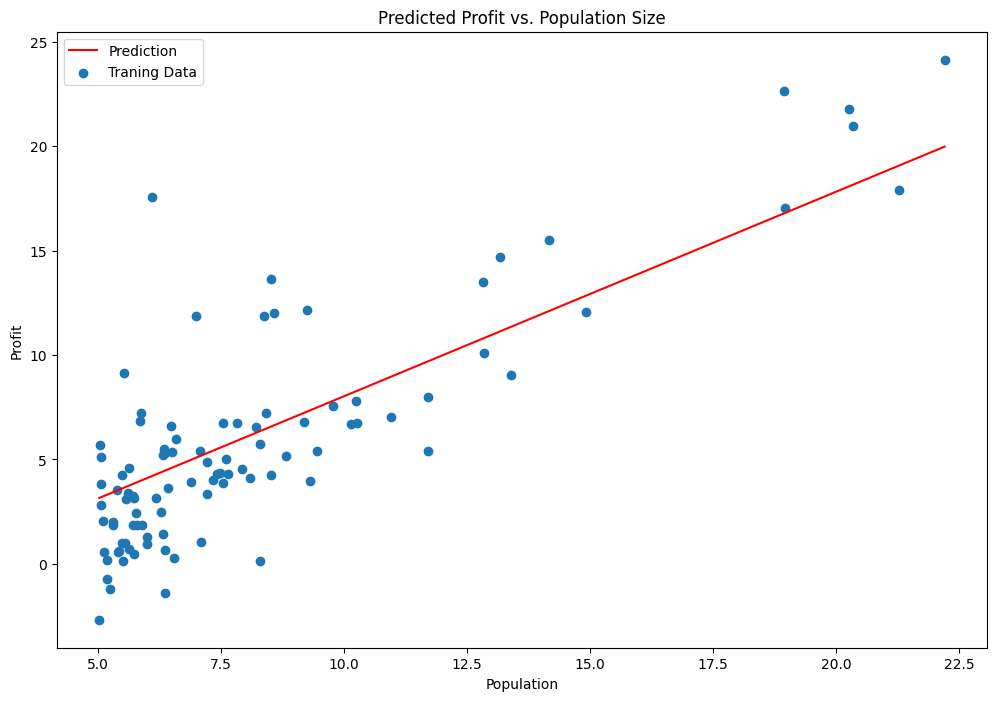

In [40]:
x = np.linspace(data.Population.min(), data.Population.max(), 100)
f = g[0, 0] + (g[0, 1] * x)

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(x, f, 'r', label='Prediction')
ax.scatter(data.Population, data.Profit, label='Traning Data')
ax.legend(loc=2)
ax.set_xlabel('Population')
ax.set_ylabel('Profit')
ax.set_title('Predicted Profit vs. Population Size')
plt.show()

由于梯度方程式函数也在每个训练迭代中输出一个代价的向量，所以我们也可以绘制。 请注意，代价总是降低 - 这是凸优化问题的一个例子。

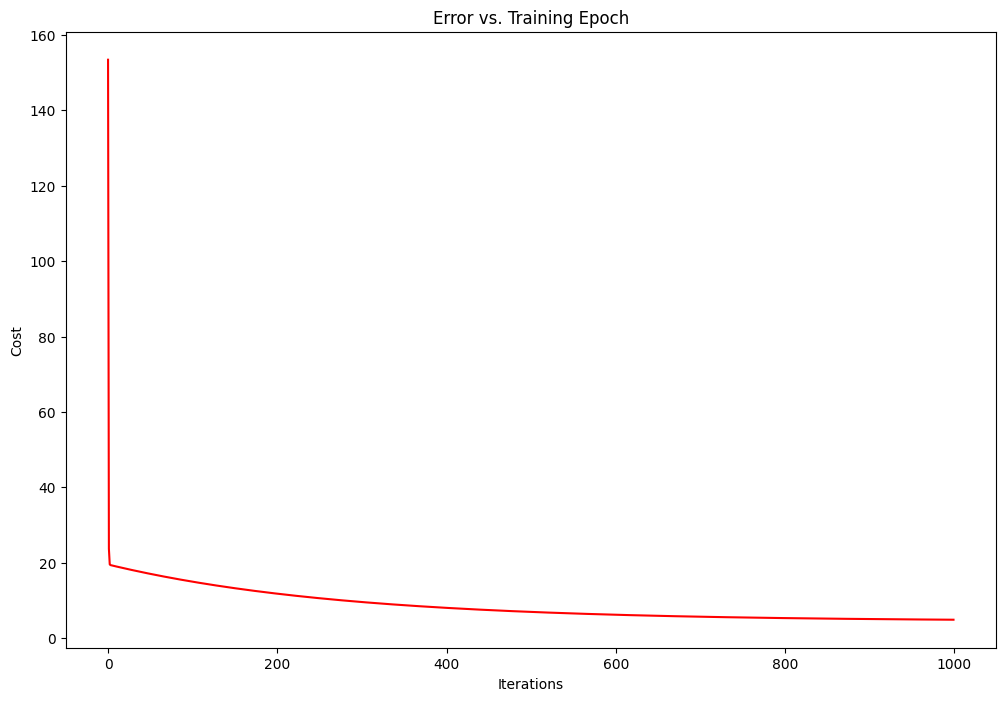

In [41]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(np.arange(iters), cost, 'r')
ax.set_xlabel('Iterations')
ax.set_ylabel('Cost')
ax.set_title('Error vs. Training Epoch')
plt.show()